# Parameter Calibration for Gas Phase
## Introduction
This Jupyter notebook (edited from (Jones and Oomen, 2024)) is used to perform Bayesian History Matching (BHM) to calibrate the gas phase chamber model to measured oxygen data. 

In [4]:
%reload_ext autoreload
%autoreload 2

## Pre-processing


In [5]:
# Import required python libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tkinter as tk
from tkinter import filedialog
import os

### Preparing data
The required data to run the BHM process includes estimated ranges for all the parameters to be calibrated and measured data to calibrate the model to. For the current process the calibration parameters are *T1* (Well 1 gas temperature), *td* (measurement delay of oxygen measurement probe), *Inlet_l2* (fraction of total chamber inlet entering Layer 2), and *Inlet_l3* (fraction of total chamber inlet entering Layer 3).

In [20]:
# Enter estimated ranges for calibraton parameters
pars = {'T1': {'limits': [20.3, 29.3]}, # Average minimum and maximum gas temperature above Well 1 from measured data
        'td' :{'limits': [5.98, 6.26]}, # Minimum and maximum delay estimated from measured data
        'Inlet_l2' : {'limits': [0.4, 0.7]}, # Roughly estimated from model testing
        'Inlet_l3' : {'limits': [0.05, 0.3]} # Roughly estimated from model testing
        }

The measured data used to calibrate the model is *TR_10* (measured oxygen partial pressure at the top right position after 10 seconds of step increase in oxygen to 21%), *TR_60* (measured oxygen partial pressure at the top right position after 60 seconds of step increase in oxygen to 21%), *TR_90* (measured oxygen partial pressure at the top right position after 90 seconds of step increase in oxygen to 21%), *BL_30* (measured oxygen partial pressure at the bottom left position after 30 seconds of step increase in oxygen to 21%), *BL_60* (measured oxygen partial pressure at the bottom left position after 60 seconds of step increase in oxygen to 21%), and *BL_90* (measured oxygen partial pressure at the bottom left position after 90 seconds of step increase in oxygen to 21%). The measured data is entered as the mean and standard deviation. 

In [ ]:
# Create dataframe with mean and standard deviation of oxygen measurements
total_o = 6 # Total number of outputs
data_mean = [2.37, 20.7, 20.9, 12.6, 20.1, 20.8]
data_std = [0.17, 0.07, 0.1, 0.57, 0.46, 0.42]
data_names = ['TR_10','TR_60','TR_90','BL_30', 'BL_60', 'BL_90']
data = pd.DataFrame(columns=['mu', 'sigma'], index=data_names) # Create dataframe
data['mu'] = data_mean
data['sigma'] = data_std
data # Display data frame

## Calibration: Running a Single Wave
The BHM process is run in iterations called 'waves'. During each wave, the model is run with an extensive parameter space, which is narrowed down using implausibilty threshold with Bayes' theorem. The input parameter space to the next wave is then the reduced parameter space from the current wave. The implausibility threshold is reduced with each wave. A single wave was first run to test the BHM process and assess the likelihood of successful model calibration. 

In [ ]:
from chameleon import Camouflage # Contains all the functions to run the BHM process
import pathlib

# Specify export directory (stores results of the BHM algorithm)
dir_nb = pathlib.Path().absolute()
dir_main = dir_nb / 'gas_cal_single_wave'

# Initialize wave
wave = Camouflage(0, dir_main, 2.0, pars, data, nroy=None, n_sim=2**8, clear_log=True, n_emu0=2**12, n_emu_min=2**12)

In [ ]:
# Import and start MATLAB engine
import matlab.engine
eng = matlab.engine.start_matlab() 

# Select gas phase model file
file_path = filedialog.askopenfilename(
    title="Please select the gas phase model file (gas_model_function.m)",
    filetypes=[("MATLAB files", "*.m")]
)

if file_path:  # Check if a file was selected
    directory_path = os.path.dirname(file_path)
    print(f"Selected file: {file_path}")
    print(f"Directory path: {directory_path}")
    # Change directory to where the chamber model is located
    eng.cd(directory_path, nargout=0)
else:
    print("No file selected")

In [22]:
# Run model
O2 = np.zeros((wave.n_sim, total_o))
for i in range(wave.n_sim):
    results = eng.gas_model_function(wave.x_sim[i, 0], wave.x_sim[i, 1], wave.x_sim[i, 2],wave.x_sim[i, 3],nargout=total_o)
    results_np = np.asarray(results)
    O2[i, :] = results_np
    
# Add to wave
wave.y_sim = O2

Gaussian Process Emulators (GPEs) are trained to emulate the model for more efficient evaluation of the parameter space. 80% of the model results are used to train the GPEs and the remaining 20% to validate the training quality.

In [ ]:
# Run wave: Train/validate emulators, emulate, calculate implausibility, find NROY
wave.surf()

# Validate emulators/plot NROY
wave.plot_r2(show_fig=True, save_fig=False)
wave.plot_nroy(show_fig=True, save_fig=True)

## Calibration: Running Multiple Waves
Once the BHM process was initially tested with the single wave, an extended process with 6 waves (maximum) was run. 

In [ ]:
# Specify export directory (stores results of BHM algorithm)
dir_main = dir_nb / "gas_cal_multiple_waves"

# Initialize wave index
i_wave = 0
nroy = None
not_flooded = True

# Start history matching until convergence or maximum number of waves is reached
while not_flooded:

    # Set wave threshold: start with 5.0 and reduce incrementally 
    wave_threshold = max(5 - 1*i_wave, 2)

    # Initialize wave    
    wave = Camouflage(i_wave, dir_main, wave_threshold, pars, data, nroy=nroy, clear_log=(i_wave == 0))

    # Run simulations for all parameter sets in current wave set x
    O2 = np.zeros((wave.n_sim, total_o))
    for i in range(wave.n_sim):
        results = eng.gas_model_function(wave.x_sim[i, 0], wave.x_sim[i, 1], wave.x_sim[i, 2],wave.x_sim[i, 3],nargout=total_o)
        results_np = np.asarray(results)
        O2[i, :] = results_np
    
    # Add to wave
    wave.y_sim = O2

    # Run wave: train/validate emulators, emulate, calculate implausibility, find NROY
    wave.surf()

    # Check for convergence, store NROY from current wave as NROY for the next wave and update counter
    not_flooded = wave.is_flooded(i_wave, min_waves=5, max_waves=6)
    nroy = wave.nroy
    i_wave += 1

## Post-processing

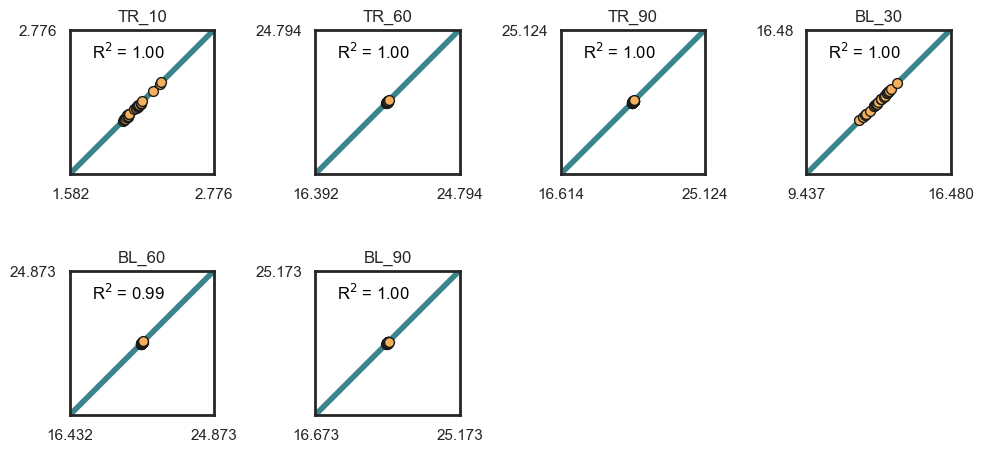

In [25]:
# Check emulator quality for final wave
wave.plot_r2(show_fig=True, save_fig=False)

 ### Run posterior simulations
Once the emulator quality was assessed, the model was run with a selection of parameter sets from the final NROY region. Each wave samples `n_posterior` parameters to be used to run your model to obtain the posterior distribution (Jones and Oomen, 2024).

In [ ]:
# Run simulations for selected parameter sets in final NROY region
O2_p = np.zeros((wave.n_posterior, total_o))
for i in range(wave.n_posterior):
    results_p = eng.gas_model_function(wave.x_posterior[i, 0], wave.x_posterior[i, 1], wave.x_posterior[i, 2],wave.x_posterior[i, 3],nargout=6)
    results_np_p = np.asarray(results_p)
    O2_p[i, :] = results_np_p
    
# Add to wave
wave.y_posterior = O2_p
wave.pickle_wave()

In [ ]:
# Store results 
x_pars_post = wave.x_posterior # Posterior parameter sets
y_pars_post = wave.y_posterior # Posterior model outputs
x_pars_post_pd = pd.DataFrame(x_pars_post)
y_pars_post_pd = pd.DataFrame(y_pars_post)
x_pars_post_pd.columns = ['T1','td','Inlet_l2','Inlet_l3']
y_pars_post_pd.columns = ['TR_10','TR_30','TR_90','BL_30','BL_60','BL_90']
x_pars_post_pd.to_csv('x_pars_post_gas_final.csv', index=False)
y_pars_post_pd.to_csv('y_pars_post_gas_final.csv', index=False)

## References
[1] Jones, C. E. & Oomen, P. J. A. Synergistic Biophysics and Machine Learning Modeling to Rapidly Predict Cardiac Growth Probability. bioRxiv 2024.07.17.603959 (2024) doi:10.1101/2024.07.17.603959.
[2] Andrianakis, I. et al. Bayesian History Matching of Complex Infectious Disease Models Using Emulation: A Tutorial and a Case Study on HIV in Uganda. Plos Comput Biol 11, e1003968 (2015).
  